<a href="https://colab.research.google.com/github/KrishnaKarthikReddy/DLL/blob/main/WEEK_11_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WEEK-11**

# **Implement Auto Encoder model on Fashion MINIST dataset.**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.3768 - val_loss: 0.3198
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3101 - val_loss: 0.3082
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3026 - val_loss: 0.3013
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2972 - val_loss: 0.2973
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2941 - val_loss: 0.2950
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2917 - val_loss: 0.2924
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2895 - val_loss: 0.2908
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2878 - val_loss: 0.2893
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2863 - val_loss: 0.2881
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2852 - val_loss: 0.2869
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2843 - val_loss: 0.2871
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

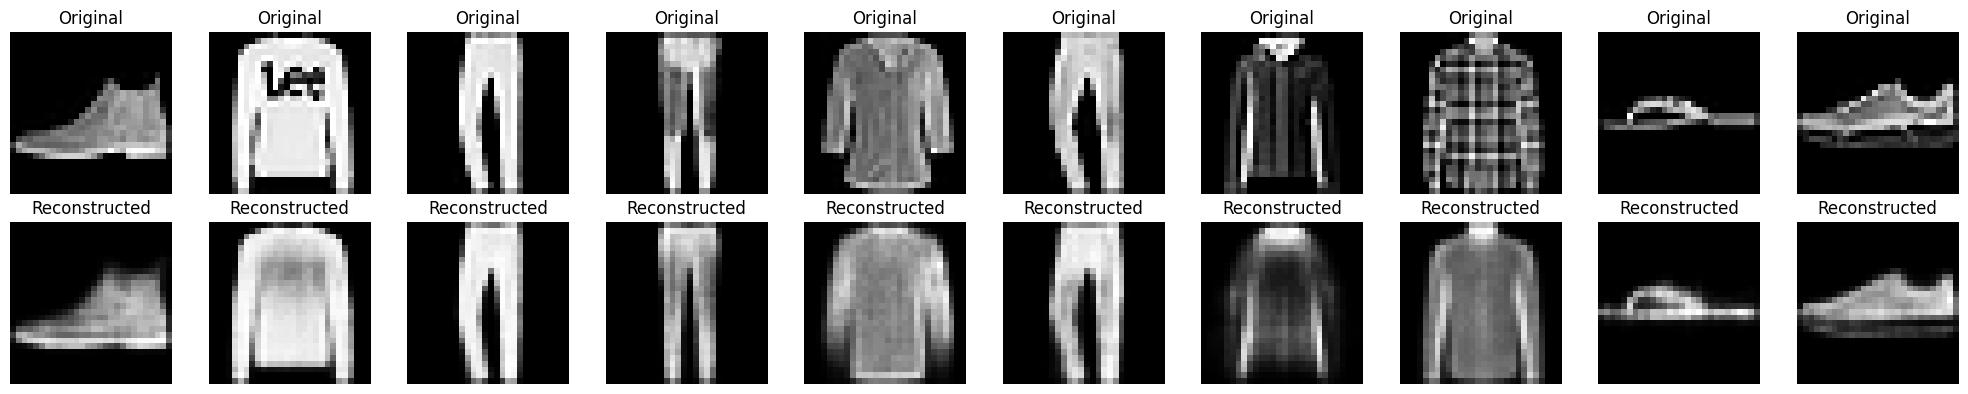

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded feature shape: (10000, 32)


In [ ]:
# ==============================
# Autoencoder on Fashion-MNIST
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# ------------------------------
# 2. Preprocessing
# ------------------------------
# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 3. Build Autoencoder
# ------------------------------
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent = Dense(32, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
output = Dense(784, activation='sigmoid')(x)

# Model
autoencoder = Model(input_img, output)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Show model summary
autoencoder.summary()

# ------------------------------
# 4. Train Model
# ------------------------------
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# ------------------------------
# 5. Reconstruct Images
# ------------------------------
decoded_imgs = autoencoder.predict(x_test[:10])

# ------------------------------
# 6. Visualization
# ------------------------------
plt.figure(figsize=(20, 4))

for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Encoder Model (Optional)
# ------------------------------
encoder = Model(input_img, latent)

encoded_imgs = encoder.predict(x_test)
print("Encoded feature shape:", encoded_imgs.shape)

# **Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)**


Training UNDERCOMPLETE AE...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3806 - val_loss: 0.3221
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3114 - val_loss: 0.3089
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3032 - val_loss: 0.3025
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2990 - val_loss: 0.2997
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2960 - val_loss: 0.2970
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2936 - val_loss: 0.2947
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2917 - val_loss: 0.2931
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2899 - val_loss: 0.2912
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2883 - val_loss: 0.2901
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2871 - val_loss: 0.2887
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2860 - val_loss: 0.2880
Epoch 12/15
235/235 ━

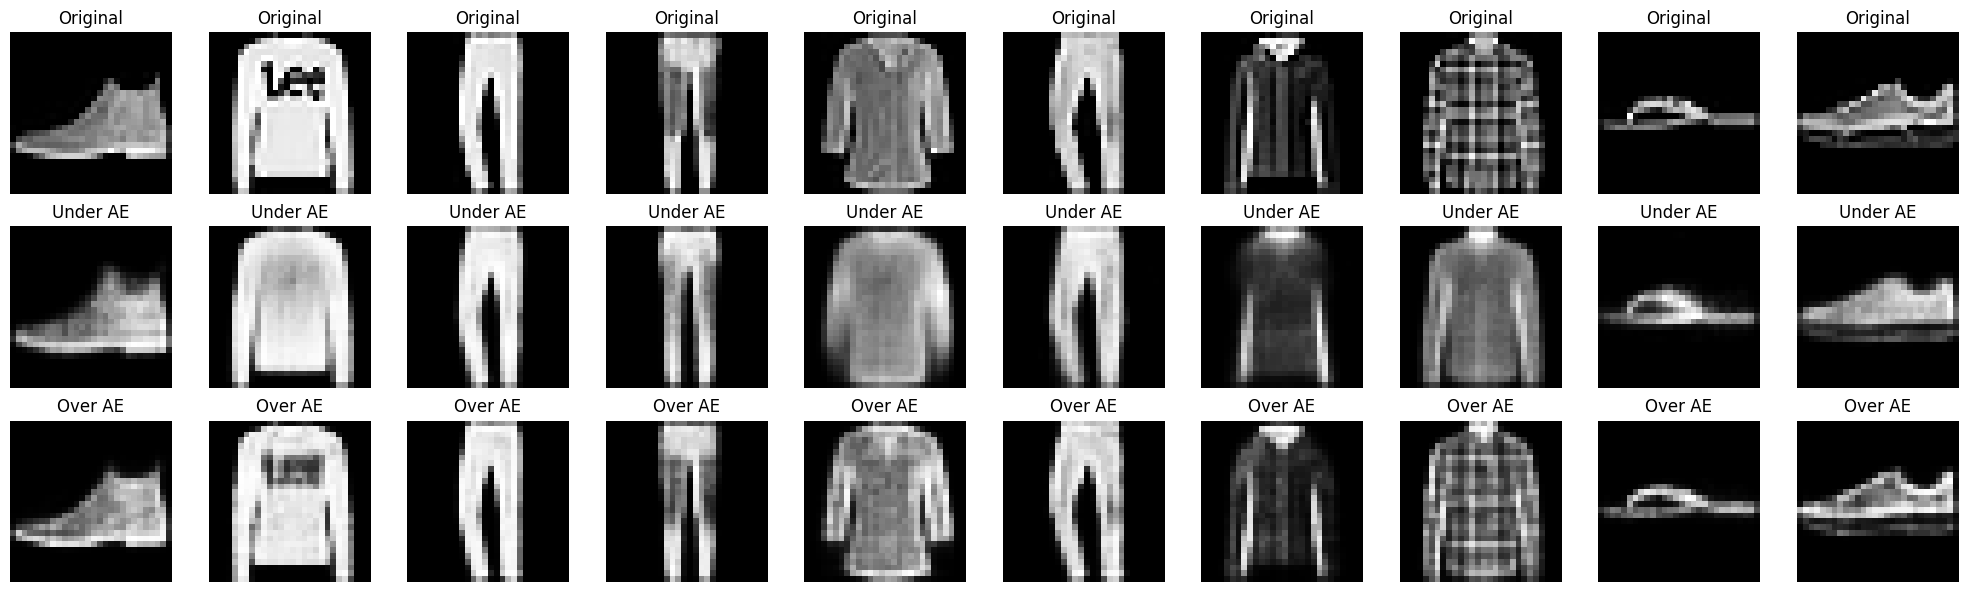

In [ ]:
# ==========================================
# Undercomplete vs Overcomplete Autoencoder
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. UNDERCOMPLETE AE
# ------------------------------
input_img = Input(shape=(784,))

# Encoder (compressed to 32)
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent_under = Dense(32, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent_under)
x = Dense(128, activation='relu')(x)
output_under = Dense(784, activation='sigmoid')(x)

under_ae = Model(input_img, output_under)
under_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining UNDERCOMPLETE AE...")
under_ae.fit(x_train, x_train,
             epochs=15,
             batch_size=256,
             validation_data=(x_test, x_test))

# ------------------------------
# 3. OVERCOMPLETE AE
# ------------------------------
input_img2 = Input(shape=(784,))

# Encoder (expanded to 1024)
x = Dense(512, activation='relu')(input_img2)
latent_over = Dense(1024, activation='relu')(x)

# Decoder
x = Dense(512, activation='relu')(latent_over)
output_over = Dense(784, activation='sigmoid')(x)

over_ae = Model(input_img2, output_over)
over_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining OVERCOMPLETE AE...")
over_ae.fit(x_train, x_train,
            epochs=15,
            batch_size=256,
            validation_data=(x_test, x_test))

# ------------------------------
# 4. Predictions
# ------------------------------
decoded_under = under_ae.predict(x_test[:10])
decoded_over = over_ae.predict(x_test[:10])

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Undercomplete
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_under[i].reshape(28, 28), cmap='gray')
    plt.title("Under AE")
    plt.axis('off')

    # Overcomplete
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_over[i].reshape(28, 28), cmap='gray')
    plt.title("Over AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Implement Regularization in AE and demonstrate its use.**


Training NORMAL AE...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3671 - val_loss: 0.3135
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3024 - val_loss: 0.2991
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2940 - val_loss: 0.2934
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2889 - val_loss: 0.2890
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2856 - val_loss: 0.2861
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2831 - val_loss: 0.2842
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2812 - val_loss: 0.2827
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2798 - val_loss: 0.2812
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2785 - val_loss: 0.2804
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2775 - val_loss: 0.2792

Training REGULARIZED AE...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.5451 - val_loss: 0.4299
E

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


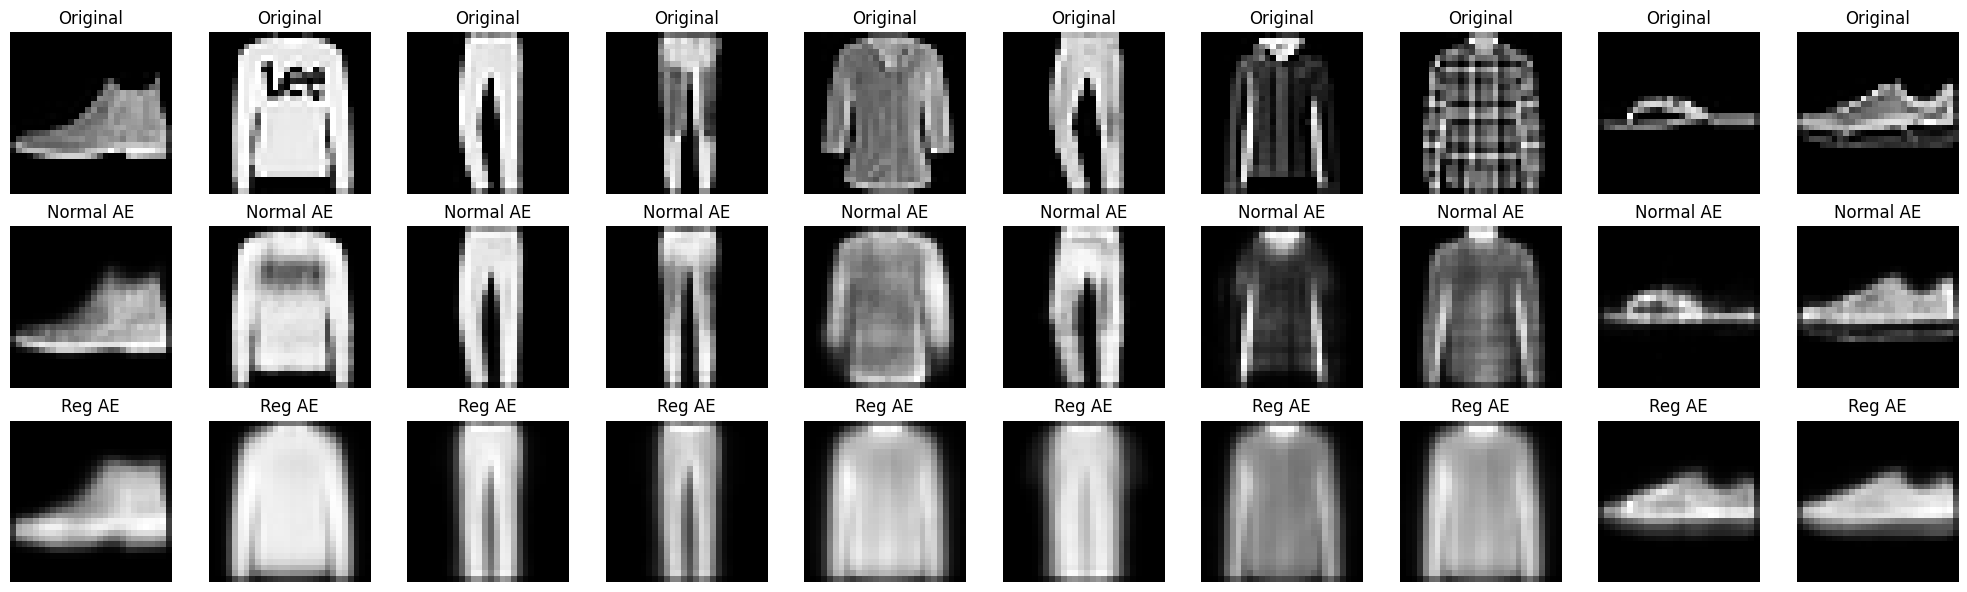

In [ ]:
# ==========================================
# Regularized Autoencoder (L1 + Dropout)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. NORMAL (Unregularized AE)
# ------------------------------
input_img = Input(shape=(784,))
x = Dense(128, activation='relu')(input_img)
latent = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(latent)
output = Dense(784, activation='sigmoid')(x)

normal_ae = Model(input_img, output)
normal_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining NORMAL AE...")
normal_ae.fit(x_train, x_train,
              epochs=10,
              batch_size=256,
              validation_data=(x_test, x_test))

# ------------------------------
# 3. REGULARIZED AE (L1 + Dropout)
# ------------------------------
input_img2 = Input(shape=(784,))

# Encoder with L1 regularization + Dropout
x = Dense(128, activation='relu',
          activity_regularizer=regularizers.l1(1e-5))(input_img2)
x = Dropout(0.3)(x)

latent_reg = Dense(64, activation='relu',
                   activity_regularizer=regularizers.l1(1e-5))(x)

# Decoder
x = Dense(128, activation='relu')(latent_reg)
x = Dropout(0.3)(x)
output_reg = Dense(784, activation='sigmoid')(x)

reg_ae = Model(input_img2, output_reg)
reg_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining REGULARIZED AE...")
reg_ae.fit(x_train, x_train,
           epochs=10,
           batch_size=256,
           validation_data=(x_test, x_test))

# ------------------------------
# 4. Predictions
# ------------------------------
decoded_normal = normal_ae.predict(x_test[:10])
decoded_reg = reg_ae.predict(x_test[:10])

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Normal AE
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_normal[i].reshape(28, 28), cmap='gray')
    plt.title("Normal AE")
    plt.axis('off')

    # Regularized AE
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_reg[i].reshape(28, 28), cmap='gray')
    plt.title("Reg AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Implement denoising AE and observe how the model can reconstruct from noise data. (write observations in terms of how much noise is acceptable)


Training Denoising AE...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3921 - val_loss: 0.3303
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3190 - val_loss: 0.3156
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3105 - val_loss: 0.3102
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3059 - val_loss: 0.3065
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3027 - val_loss: 0.3036
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3002 - val_loss: 0.3016
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2983 - val_loss: 0.3005
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2967 - val_loss: 0.2984
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2953 - val_loss: 0.2988
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2943 - val_loss: 0.2966
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2932 - val_loss: 0.2955
Epoch 12/15
235/235 ━━━━━

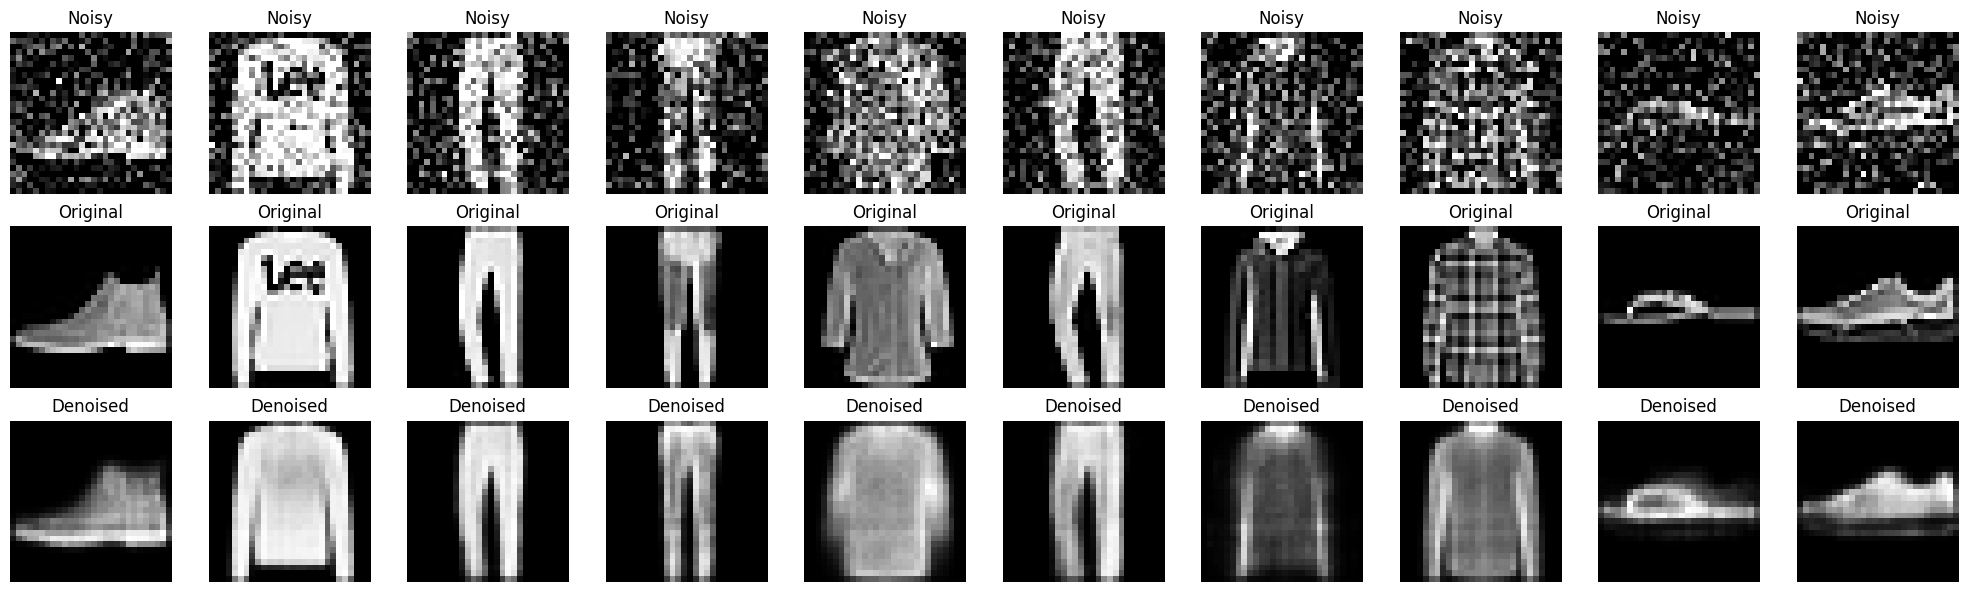

In [ ]:
# ==========================================
# Denoising Autoencoder (DAE)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. Add Noise
# ------------------------------
noise_factor = 0.3   # Try 0.1, 0.3, 0.5 for analysis

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values to [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ------------------------------
# 3. Build Autoencoder
# ------------------------------
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent = Dense(32, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
output = Dense(784, activation='sigmoid')(x)

dae = Model(input_img, output)
dae.compile(optimizer='adam', loss='binary_crossentropy')

# ------------------------------
# 4. Train Model
# ------------------------------
print("\nTraining Denoising AE...")
dae.fit(x_train_noisy, x_train,
        epochs=15,
        batch_size=256,
        validation_data=(x_test_noisy, x_test))

# ------------------------------
# 5. Predict (Denoised Output)
# ------------------------------
decoded_imgs = dae.predict(x_test_noisy[:10])

# ------------------------------
# 6. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Noisy Input
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Clean Original
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Demonstrate PCA with AE on a dataset.**


Applying PCA...

Training Autoencoder...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.3774 - val_loss: 0.3182
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3099 - val_loss: 0.3070
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3018 - val_loss: 0.3010
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2968 - val_loss: 0.2969
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2935 - val_loss: 0.2941
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2911 - val_loss: 0.2922
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2891 - val_loss: 0.2908
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2876 - val_loss: 0.2894
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2864 - val_loss: 0.2880
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2854 - val_loss: 0.2871
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2843 - val_loss: 0.2861
Epoch 12/

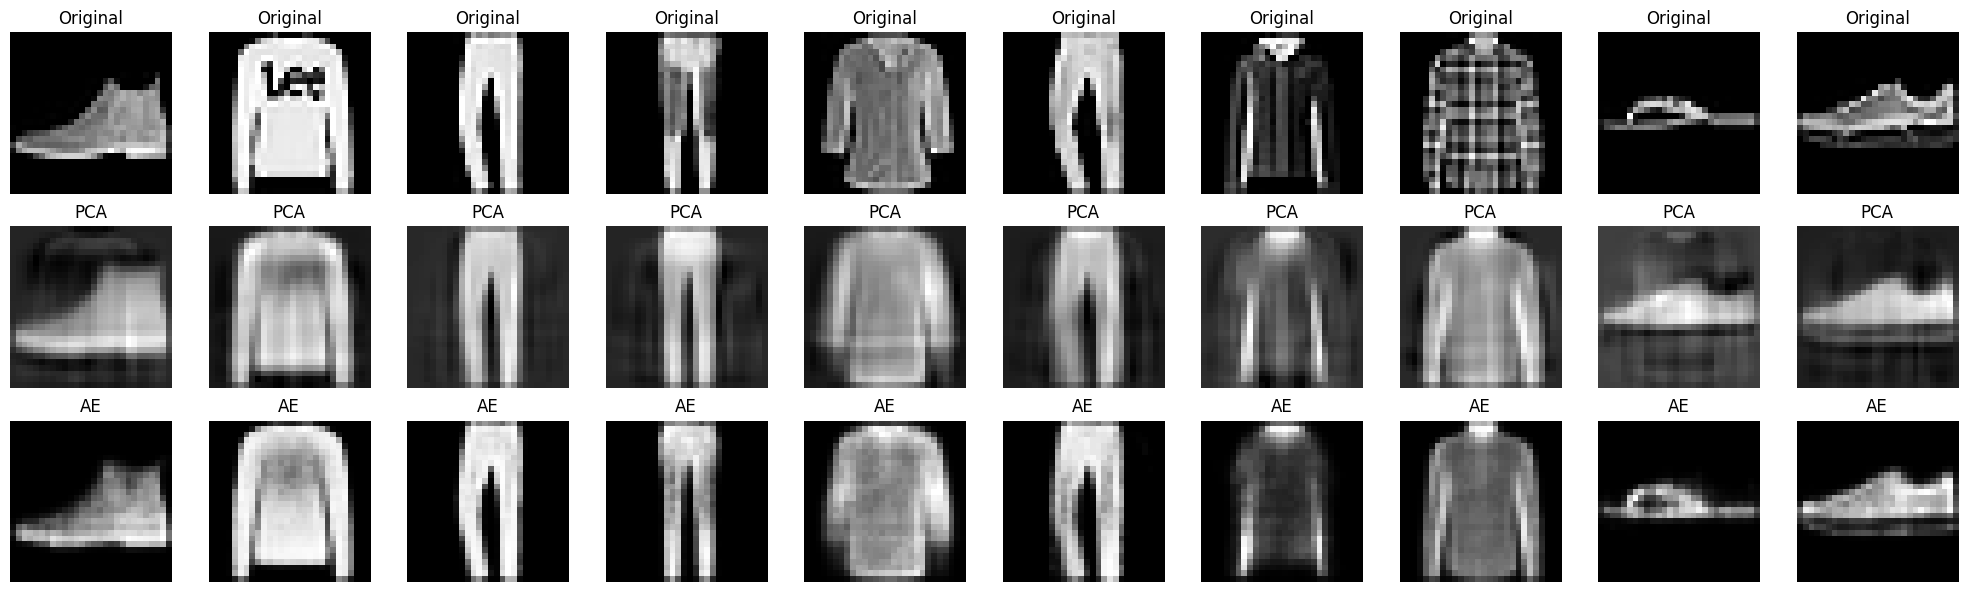

In [ ]:
# ==========================================
# PCA vs Autoencoder (AE)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. PCA Implementation
# ------------------------------
latent_dim = 32

print("\nApplying PCA...")
pca = PCA(n_components=latent_dim)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# Reconstruct from PCA
x_test_pca_recon = pca.inverse_transform(x_test_pca)

# ------------------------------
# 3. Autoencoder Implementation
# ------------------------------
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent = Dense(latent_dim, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
output = Dense(784, activation='sigmoid')(x)

ae = Model(input_img, output)
ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining Autoencoder...")
ae.fit(x_train, x_train,
       epochs=15,
       batch_size=256,
       validation_data=(x_test, x_test))

# Reconstruct using AE
x_test_ae_recon = ae.predict(x_test)

# ------------------------------
# 4. Compare Reconstruction Error
# ------------------------------
pca_mse = mean_squared_error(x_test, x_test_pca_recon)
ae_mse = mean_squared_error(x_test, x_test_ae_recon)

print("\nReconstruction Error:")
print("PCA MSE:", pca_mse)
print("AE  MSE:", ae_mse)

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # PCA Reconstruction
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(x_test_pca_recon[i].reshape(28, 28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')

    # AE Reconstruction
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(x_test_ae_recon[i].reshape(28, 28), cmap='gray')
    plt.title("AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Implement Sparse AE and Contractive AE.**


Training Sparse Autoencoder...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.5119 - val_loss: 0.4086
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3832 - val_loss: 0.3659
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3559 - val_loss: 0.3514
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3445 - val_loss: 0.3409
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3347 - val_loss: 0.3331
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3290 - val_loss: 0.3302
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3253 - val_loss: 0.3260
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3226 - val_loss: 0.3234
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3204 - val_loss: 0.3216
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3185 - val_loss: 0.3201
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3170 - val_loss: 0.3181
Epoch 12/15
235/235

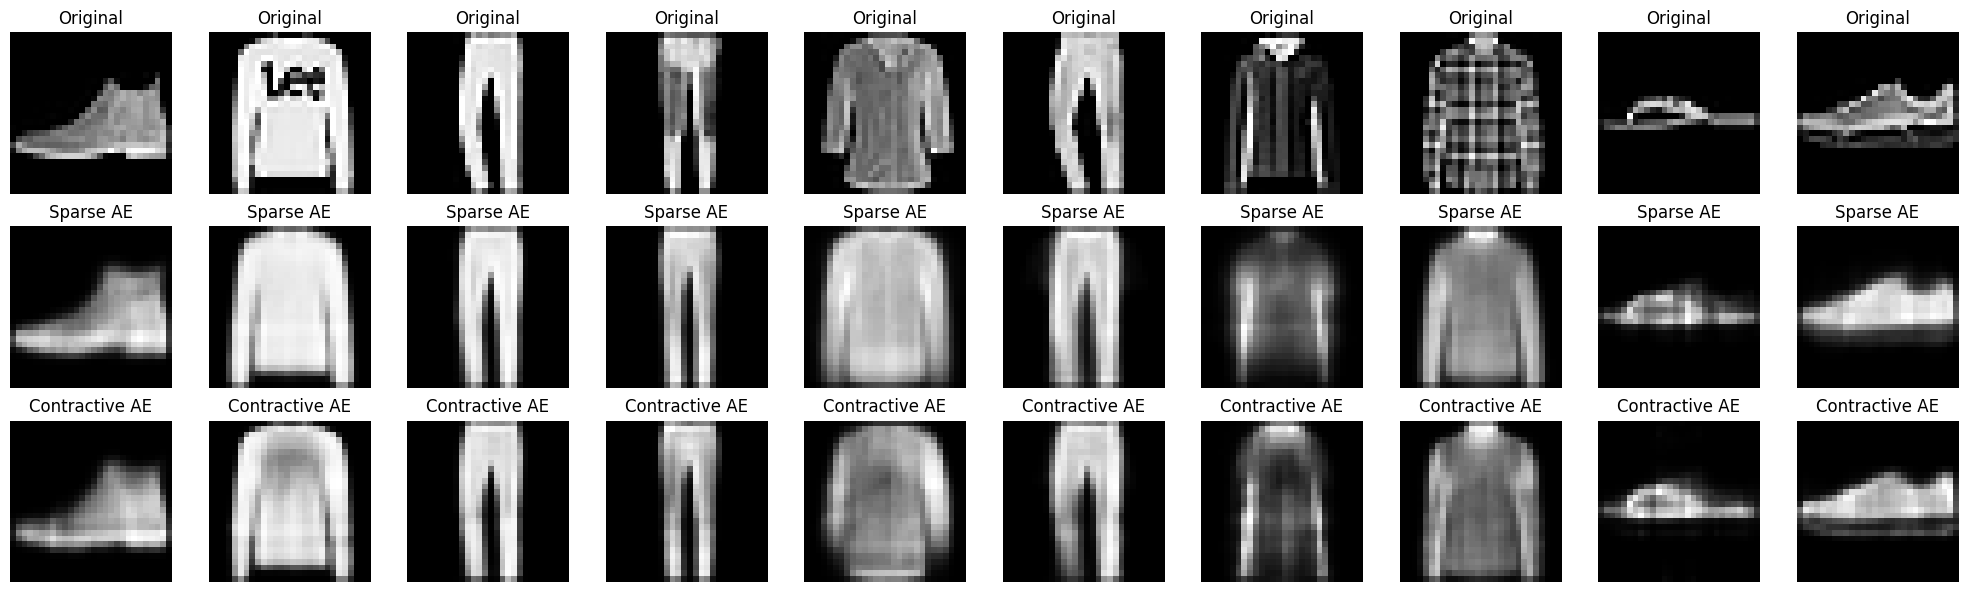

In [ ]:
# ==========================================
# Sparse AE + Contractive AE (FINAL FIXED)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. Sparse Autoencoder (L1)
# ------------------------------
input_img = Input(shape=(784,))

x = Dense(128, activation='relu',
          activity_regularizer=regularizers.l1(1e-5))(input_img)
latent_sparse = Dense(32, activation='relu',
                      activity_regularizer=regularizers.l1(1e-5))(x)

x = Dense(128, activation='relu')(latent_sparse)
output_sparse = Dense(784, activation='sigmoid')(x)

sparse_ae = Model(input_img, output_sparse)
sparse_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining Sparse Autoencoder...")
sparse_ae.fit(
    x_train, x_train,
    epochs=15,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# ------------------------------
# 3. Contractive Autoencoder
# ------------------------------
class ContractiveAE(Model):
    def __init__(self):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            Dense(128, activation='relu'),
            Dense(32, activation='sigmoid')
        ])

        self.decoder = tf.keras.Sequential([
            Dense(128, activation='relu'),
            Dense(784, activation='sigmoid')
        ])

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def train_step(self, data):
        x, _ = data  # IMPORTANT

        with tf.GradientTape() as tape:
            z = self.encoder(x)
            x_hat = self.decoder(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(x, x_hat)
            )

            # Contractive loss
            dh = z * (1 - z)  # sigmoid derivative
            W = self.encoder.layers[-1].kernel

            contractive_loss = tf.reduce_sum(
                tf.square(dh) * tf.reduce_sum(tf.square(W), axis=0),
                axis=1
            )
            contractive_loss = tf.reduce_mean(contractive_loss)

            total_loss = recon_loss + 1e-4 * contractive_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {
            "loss": total_loss,
            "recon_loss": recon_loss,
            "contractive_loss": contractive_loss
        }

# Initialize + IMPORTANT dummy loss
contractive_ae = ContractiveAE()
contractive_ae.compile(optimizer='adam', loss='mse')

print("\nTraining Contractive Autoencoder...")
contractive_ae.fit(
    x_train, x_train,
    epochs=15,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# ------------------------------
# 4. Predictions
# ------------------------------
decoded_sparse = sparse_ae.predict(x_test[:10])
decoded_contractive = contractive_ae.predict(x_test[:10])

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Sparse AE
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_sparse[i].reshape(28, 28), cmap='gray')
    plt.title("Sparse AE")
    plt.axis('off')

    # Contractive AE
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_contractive[i].reshape(28, 28), cmap='gray')
    plt.title("Contractive AE")
    plt.axis('off')

plt.tight_layout()
plt.show()